# CareerAI Agent — Debug Notebook

Peek inside the auto-apply agent on **any single page**. Each cell shows one
stage of what the agent does — so you can see exactly what the LLM sees, what
it sends back, and how the DOM scan works.

**How to use:** open this file in VS Code, change `URL` in Cell 4 to the page
you want to inspect, then run cells top-to-bottom with **Shift+Enter**.

Pipeline:
1. **Settle** — wait until the page stops mutating.
2. **Scan DOM** — pierce shadow roots, collect every interactive element,
   label it, tag widget type (`typeahead` / `select`), inject
   `data-agent-idx="N"` so we can target it later.
3. **Set-of-marks** — draw red numbered boxes on the screenshot. This is
   the *visual* grounding the LLM uses; the numbers are the indices.
4. **Element-list text** — the *textual* description we also hand the LLM.
5. **Context** — profile + résumé + portal memory.
6. **Plan** — one LLM call → JSON list of actions.
7. **Map back** — see which red box each planned action targets.
8. **(Optional) Execute one action and re-scan** to see the DOM diff.

In [1]:
import os, sys, json, base64, asyncio, threading
from pathlib import Path
from concurrent.futures import Future

# Jupyter on Windows runs a SelectorEventLoop (Tornado), which cannot spawn
# subprocesses -> Playwright's driver fails to launch. Setting the policy in
# this cell does NOT help because the kernel's loop is already created.
# Workaround: run all Playwright coroutines on a dedicated background thread
# whose loop is a ProactorEventLoop.
class _AsyncRunner:
    def __init__(self):
        if sys.platform == "win32":
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        self.loop = asyncio.new_event_loop()
        self._ready = threading.Event()
        self.thread = threading.Thread(target=self._serve, daemon=True)
        self.thread.start()
        self._ready.wait()

    def _serve(self):
        asyncio.set_event_loop(self.loop)
        self._ready.set()
        self.loop.run_forever()

    def run(self, coro):
        return asyncio.run_coroutine_threadsafe(coro, self.loop).result()

    def stop(self):
        self.loop.call_soon_threadsafe(self.loop.stop)

# Singleton: reuse across cells so `page` etc. stay bound to the same loop.
_BG = globals().get("_BG") or _AsyncRunner()
R   = _BG.run

# Make the project importable when launching from inside this folder.
sys.path.insert(0, str(Path.cwd()))

from dotenv import load_dotenv
load_dotenv()

# Pull the helpers straight from the agent so we observe its actual behaviour.
from auto_agent import (
    settle, collect_elements, elements_to_text, annotate_screenshot,
    plan_page, _context, execute_action, FLASH_MODEL,
)
from profile_manager import load_profile
from job_wiki import get_portal_knowledge

from IPython.display import Image, display

print("LLM driver :", os.getenv("APPLY_LLM"), "·", os.getenv("APPLY_MODEL"))
print("Email      :", (os.getenv("APPLY_EMAIL") or "")[:3] + "***")
print("CWD        :", Path.cwd())
print("Async loop :", type(_BG.loop).__name__, "(thread alive:", _BG.thread.is_alive(), ")")


LLM driver : openai · gpt-5.4-mini
Email      : dee***
CWD        : D:\Projects\Resume_Builder
Async loop : ProactorEventLoop (thread alive: True )


## 1. Open the page

We launch Chromium with the **same persistent profile** the real agent uses
(`browser_profile/`), so any session cookies you already have will apply.
The browser opens visibly on your screen — you can watch the page load.

In [2]:
from playwright.async_api import async_playwright

URL = "https://jobs.sap.com/job/Bangalore-Senior-Machine-Learning-Engineer-KA-562149/1388330833/?feedId=384233"  # ← change me
PROFILE_DIR = Path("browser_profile")

_p  = R(async_playwright().start())
ctx = R(_p.chromium.launch_persistent_context(
    str(PROFILE_DIR),
    headless=True,
    args=["--disable-blink-features=AutomationControlled", "--no-sandbox"],
    viewport={"width": 1280, "height": 900},
))
page = ctx.pages[0] if ctx.pages else R(ctx.new_page())
R(page.goto(URL, wait_until="domcontentloaded"))
print("URL  :", page.url)
print("Title:", R(page.title()))


URL  : https://jobs.sap.com/job/Bangalore-Senior-Machine-Learning-Engineer-KA-562149/1388330833/?feedId=384233
Title: Senior Machine Learning Engineer Job Details | SAP


## 2. Settle-gate

Web forms render asynchronously — fields appear / shift after the first paint.
If we read the DOM mid-render, our indices may be stale by the time the LLM
answers. `settle()` waits until **the network is idle AND the DOM stops
mutating for ~500ms.**

In [3]:
R(settle(page))
print("Settled.")


Settled.


## 3. Scan the DOM

`collect_elements()` runs a JavaScript pass (`_COLLECT_JS` in `auto_agent.py`)
that:

- Pierces **shadow roots** (modern web components hide their fields there).
- Picks every visible `input`, `textarea`, `select`, `button`,
  `[role=button|checkbox|radio]`, and `[contenteditable]`.
- Derives a **label** in this priority order: `aria-label` → `aria-labelledby`
  → `label[for=id]` → wrapping `<label>` → nearby preceding text → `name` attr.
- Records the **viewport box** `[x, y, w, h]` (used to draw the red marks).
- Tags **widget type**: native `<select>` → `select`; `role=combobox` /
  `aria-autocomplete` / `aria-haspopup=listbox` → `typeahead`.
- Injects `data-agent-idx="N"` so we can later target the element with a
  stable CSS selector regardless of how it's nested.

`idx_frame` maps each element's `idx` to the Playwright frame it lives in —
important because many ATS pages live inside iframes.

In [4]:
elements, idx_frame = R(collect_elements(page))
print(f"Found {len(elements)} interactive elements.\n")
for e in elements[:10]:
    print(e)
print("\n...(showing first 10)")


Found 24 interactive elements.

{'idx': 0, 'tag': 'a', 'type': None, 'label': 'Apply now »', 'box': [120, 357, 118, 43]}
{'idx': 1, 'tag': 'a', 'type': None, 'label': 'SAP Employee Referral Program', 'box': [514, 2214, 223, 19]}
{'idx': 2, 'tag': 'a', 'type': None, 'label': 'Guidelines for Ethical Usage of AI in the Recruiting Process', 'box': [90, 2488, 721, 42]}
{'idx': 3, 'tag': 'a', 'type': None, 'label': 'Apply now »', 'box': [941, 591, 118, 43]}
{'idx': 4, 'tag': 'a', 'type': None, 'label': 'SAP Jobs in India,', 'box': [941, 1067, 106, 17]}
{'idx': 5, 'tag': 'a', 'type': None, 'label': 'Engineering Jobs in India,', 'box': [941, 1067, 222, 36]}
{'idx': 6, 'tag': 'a', 'type': None, 'label': 'Developer Jobs in India,', 'box': [978, 1086, 139, 17]}
{'idx': 7, 'tag': 'a', 'type': None, 'label': 'Computer Science Jobs in Bangalore,', 'box': [941, 1105, 212, 17]}
{'idx': 8, 'tag': 'a', 'type': None, 'label': 'Asia-Pacific Development & Technology', 'box': [941, 1124, 164, 36]}
{'idx': 9

## 4. Set-of-marks — what the LLM "sees"

We draw a red numbered box on every element. **This is the screenshot the
LLM receives.** The numbers in the boxes are the `idx` values — the LLM
refers to elements by these in its plan ("fill `[5]` with 'Bengaluru'").

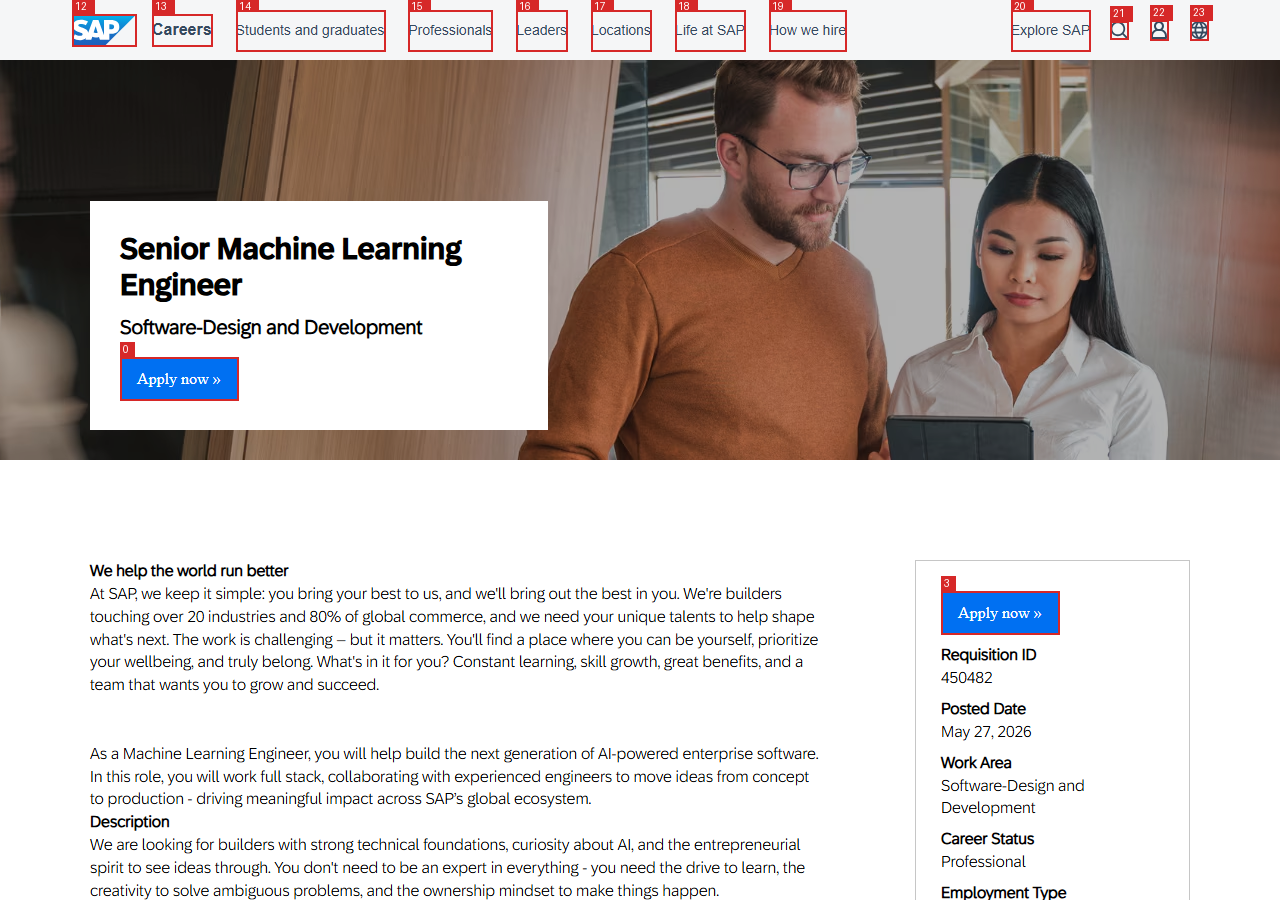

In [5]:
raw_png    = R(page.screenshot(full_page=False))
marked_png = annotate_screenshot(raw_png, elements)
display(Image(data=marked_png))


## 5. Element-list text — the textual description

Alongside the screenshot, we send a structured **text list** of every
element. Look for the widget tags (`<typeahead>`, `<select>`), `REQUIRED`
markers, current values, and option lists — that's the model's "reading"
of the page.

In [6]:
elements_text = elements_to_text(elements)
print(elements_text)

[0] a "Apply now »"
[1] a "SAP Employee Referral Program"
[2] a "Guidelines for Ethical Usage of AI in the Recruiting Process"
[3] a "Apply now »"
[4] a "SAP Jobs in India,"
[5] a "Engineering Jobs in India,"
[6] a "Developer Jobs in India,"
[7] a "Computer Science Jobs in Bangalore,"
[8] a "Asia-Pacific Development & Technology"
[9] input number REQUIRED "Select how often (in days) to receive an alert:" (current: 7)
[10] button "Create Alert"
[11] a "Let us know"
[12] a "SAP Logo"
[13] a "Careers"
[14] a "Students and graduates"
[15] button
[16] a "Leaders"
[17] a "Locations"
[18] button
[19] button
[20] button
[21] button "Open search"
[22] button "Profile"
[23] button "Country Selector"


## 6. The context we hand the model

`_context()` builds the prompt context: your **profile**, your **résumé**
(truncated to ~12 000 chars), and **portal memory** for this domain —
`account_on_file`, previously filled values, previously asked questions,
known stuck-issues. Without this the LLM has no idea who you are.

In [7]:
USER_ID     = 1
profile     = load_profile(USER_ID)
resume_text = profile.get("_resume_text", "")
known       = get_portal_knowledge(URL)

ctx_str = _context(profile, resume_text, known)
print(ctx_str[:4000])
if len(ctx_str) > 4000:
    print(f"\n... (truncated; full context is {len(ctx_str)} chars)")

PROFILE:
{
  "full_name": "DEEPAK KUMAR",
  "first_name": "DEEPAK",
  "last_name": "KUMAR",
  "phone": "9780616787",
  "phone_country_code": "+91",
  "city": "Bengaluru",
  "country": "India",
  "linkedin": "linkedin.com/in/mustangs007",
  "current_company": "Optum",
  "current_title": "AI/ML Applied Scientist",
  "years_experience": "5 years 7 months",
  "notice_period": "90",
  "expected_ctc": "60 lpa",
  "current_ctc": "40 lpa",
  "graduation_year": "2027",
  "degree": "MTech",
  "university": "IIT Hyderabad",
  "screening": {
    "your choice will guide how we manage your data across our systems and help us create a more personalized experience for you. you can update your profile sharing": "Use my profile data for only the role I\u2019",
    "address 1": "Bengaluru",
    "city": "Bengaluru",
    "postal code": "560103",
    "what percentage are you willing to travel?": "0",
    "what is your highest level of education?": "MTech",
    "what is your level of completion?": "In Progre

## 7. Ask the LLM to plan the page

`plan_page()` sends:

- The **context** (Cell 6),
- The **element list text** (Cell 5),
- A short "recent steps" log,
- Optionally the **marked screenshot** (we include it here so you see the
  richest possible call),

…and asks for **one JSON plan** describing what to do on this page. The
routing between Gemini and Azure OpenAI is decided by `APPLY_LLM` in `.env`.

In [8]:
# We need a Gemini client for the function signature even if APPLY_LLM is
# "openai" — `apply_llm.llm_json` picks the actual driver from the env var.
from google import genai
gemini_client = genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))

img_b64 = base64.b64encode(marked_png).decode()
plan = plan_page(
    gemini_client, FLASH_MODEL, ctx_str, elements_text,
    "(no prior steps in this debug run)", page.url,
    img_b64=img_b64,
)
print(json.dumps(plan, indent=2))

{
  "page_type": "other",
  "actions": [
    {
      "index": 0,
      "action": "click",
      "label": "Apply now \u00bb"
    },
    {
      "index": 3,
      "action": "click",
      "label": "Apply now \u00bb"
    }
  ],
  "advance": {
    "action": "next",
    "index": 0
  }
}


## 8. Map the plan back to elements

The plan refers to elements by their `index`. Here we look each one up so
you can see exactly **which red-box gets what value** — and which fields the
planner skipped.

In [9]:
def _lookup(i):
    return next((e for e in elements if e["idx"] == i), {})

print(f"page_type: {plan.get('page_type')}\n")
print("ACTIONS:")
for a in plan.get("actions", []):
    e   = _lookup(a.get("index"))
    lab = a.get("label") or e.get("label") or e.get("q") or "?"
    val = a.get("value") or a.get("question") or e.get("option") or ""
    w   = f" <{e.get('widget')}>" if e.get("widget") else ""
    print(f"  [{a.get('index')}] {a.get('action')}{w}  '{lab}'  → {val}")

adv = plan.get("advance") or {}
adv_el = _lookup(adv.get("index"))
print(f"\nADVANCE: {adv.get('action')}  [{adv.get('index')}]  '{adv_el.get('label','')}'")

page_type: other

ACTIONS:
  [0] click  'Apply now »'  → 
  [3] click  'Apply now »'  → 

ADVANCE: next  [0]  'Apply now »'


## 9. (Optional) Execute one action and watch the DOM diff

Run the planner's **first** action, settle, re-scan, and print which fields
appeared / disappeared. This is how the agent catches **revealed fields**
(e.g. selecting *Country = India* makes a *State* dropdown appear).

In [10]:
creds = {"email": os.getenv("APPLY_EMAIL", ""), "password": os.getenv("APPLY_PASSWORD", "")}

if plan.get("actions"):
    first = plan["actions"][0]
    print("Executing:", first)
    ok, note = R(execute_action(page, first, idx_frame, elements, "", creds))
    print("→", ok, note)

    R(settle(page))
    before_keys = {e["idx"] for e in elements}
    elements2, _ = R(collect_elements(page))
    after_keys  = {e["idx"] for e in elements2}

    new_idx     = sorted(after_keys - before_keys)[:15]
    print(f"\nRe-scan: {len(elements2)} elements (was {len(elements)}).")
    print(f"New idx after action: {new_idx}")
    for i in new_idx[:5]:
        print("  •", next((e for e in elements2 if e["idx"] == i), {}))
else:
    print("(no actions to execute)")


Executing: {'index': 0, 'action': 'click', 'label': 'Apply now »'}


→ True click [0] Apply now »



Re-scan: 6 elements (was 24).
New idx after action: []


## 10. Cleanup

Close the browser when you're done. Skip if you want to keep poking — you
can re-run Cells 2–8 to see how the page evolves after manual interactions.

In [11]:
R(ctx.close())
R(_p.stop())
print("Closed.")


Closed.
